In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
import pickle
import warnings
warnings.filterwarnings('ignore')

In [92]:
df=pd.read_csv(r'C:\Users\maa\Desktop\PYTHON\My_Projects\Churn_Prediction_System\data\Spotify_data.csv',encoding='latin-1')
print(df.head())

     Age  Gender spotify_usage_period  \
0  20-35  Female    More than 2 years   
1  12-20    Male    More than 2 years   
2  35-60  Others   6 months to 1 year   
3  20-35  Female    1 year to 2 years   
4  20-35  Female    1 year to 2 years   

                         spotify_listening_device spotify_subscription_plan  \
0              Smart speakers or voice assistants       Free (ad-supported)   
1                              Computer or laptop       Free (ad-supported)   
2              Smart speakers or voice assistants       Free (ad-supported)   
3  Smartphone, Smart speakers or voice assistants       Free (ad-supported)   
4                                      Smartphone       Free (ad-supported)   

  premium_sub_willingness          preffered_premium_plan  \
0                     Yes        Family Plan-Rs 179/month   
1                     Yes  Individual Plan- Rs 119/ month   
2                     Yes        Student Plan-Rs 59/month   
3                      No         

In [93]:
print(df.tail(15))

       Age  Gender spotify_usage_period  \
505  20-35  Female    1 year to 2 years   
506  20-35    Male   Less than 6 months   
507  20-35  Female   Less than 6 months   
508  12-20  Female   6 months to 1 year   
509  20-35  Female    More than 2 years   
510  20-35    Male    More than 2 years   
511  20-35  Female    More than 2 years   
512  20-35  Female    More than 2 years   
513  20-35  Female    More than 2 years   
514  20-35  Female    More than 2 years   
515  20-35  Female    More than 2 years   
516  20-35  Female    More than 2 years   
517  20-35  Female    More than 2 years   
518  20-35  Female   6 months to 1 year   
519  20-35  Female    More than 2 years   

                              spotify_listening_device  \
505                                   Wearable devices   
506                 Smart speakers or voice assistants   
507                                 Computer or laptop   
508                                   Wearable devices   
509                  

In [94]:
print(df.shape)

(520, 20)


In [95]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Age                          520 non-null    object
 1   Gender                       520 non-null    object
 2   spotify_usage_period         520 non-null    object
 3   spotify_listening_device     520 non-null    object
 4   spotify_subscription_plan    520 non-null    object
 5   premium_sub_willingness      520 non-null    object
 6   preffered_premium_plan       312 non-null    object
 7   preferred_listening_content  520 non-null    object
 8   fav_music_genre              520 non-null    object
 9   music_time_slot              520 non-null    object
 10  music_Influencial_mood       520 non-null    object
 11  music_lis_frequency          520 non-null    object
 12  music_expl_method            520 non-null    object
 13  music_recc_rating            520 no

In [96]:
print(df.isnull().sum())

Age                              0
Gender                           0
spotify_usage_period             0
spotify_listening_device         0
spotify_subscription_plan        0
premium_sub_willingness          0
preffered_premium_plan         208
preferred_listening_content      0
fav_music_genre                  0
music_time_slot                  0
music_Influencial_mood           0
music_lis_frequency              0
music_expl_method                0
music_recc_rating                0
pod_lis_frequency                0
fav_pod_genre                  148
preffered_pod_format           140
pod_host_preference            141
preffered_pod_duration         129
pod_variety_satisfaction         0
dtype: int64


In [97]:
pd.set_option('display.max_columns',None)
print(df.head(3))

     Age  Gender spotify_usage_period            spotify_listening_device  \
0  20-35  Female    More than 2 years  Smart speakers or voice assistants   
1  12-20    Male    More than 2 years                  Computer or laptop   
2  35-60  Others   6 months to 1 year  Smart speakers or voice assistants   

  spotify_subscription_plan premium_sub_willingness  \
0       Free (ad-supported)                     Yes   
1       Free (ad-supported)                     Yes   
2       Free (ad-supported)                     Yes   

           preffered_premium_plan preferred_listening_content fav_music_genre  \
0        Family Plan-Rs 179/month                     Podcast          Melody   
1  Individual Plan- Rs 119/ month                     Podcast             Rap   
2        Student Plan-Rs 59/month                     Podcast             Pop   

  music_time_slot        music_Influencial_mood           music_lis_frequency  \
0           Night         Sadness or melancholy                 

In [98]:
for col in df.columns:
    print(col,df[col].unique())
    print('-------------------')

Age ['20-35' '12-20' '35-60' '60+']
-------------------
Gender ['Female' 'Male' 'Others']
-------------------
spotify_usage_period ['More than 2 years' '6 months to 1 year' '1 year to 2 years'
 'Less than 6 months']
-------------------
spotify_listening_device ['Smart speakers or voice assistants' 'Computer or laptop'
 'Smartphone, Smart speakers or voice assistants' 'Smartphone'
 'Smartphone, Computer or laptop'
 'Smartphone, Computer or laptop, Smart speakers or voice assistants'
 'Smartphone, Wearable devices'
 'Smartphone, Computer or laptop, Wearable devices'
 'Computer or laptop, Wearable devices'
 'Smartphone, Computer or laptop, Smart speakers or voice assistants, Wearable devices'
 'Wearable devices'
 'Smartphone, Smart speakers or voice assistants, Wearable devices'
 'Computer or laptop, Smart speakers or voice assistants'
 'Computer or laptop, Smart speakers or voice assistants, Wearable devices'
 'Smart speakers or voice assistants, Wearable devices']
-------------------
sp

In [99]:
print(df['premium_sub_willingness'].value_counts())

premium_sub_willingness
No     334
Yes    186
Name: count, dtype: int64


In [100]:
print(df.columns)

Index(['Age', 'Gender', 'spotify_usage_period', 'spotify_listening_device',
       'spotify_subscription_plan', 'premium_sub_willingness',
       'preffered_premium_plan', 'preferred_listening_content',
       'fav_music_genre', 'music_time_slot', 'music_Influencial_mood',
       'music_lis_frequency', 'music_expl_method', 'music_recc_rating',
       'pod_lis_frequency', 'fav_pod_genre', 'preffered_pod_format',
       'pod_host_preference', 'preffered_pod_duration',
       'pod_variety_satisfaction'],
      dtype='object')


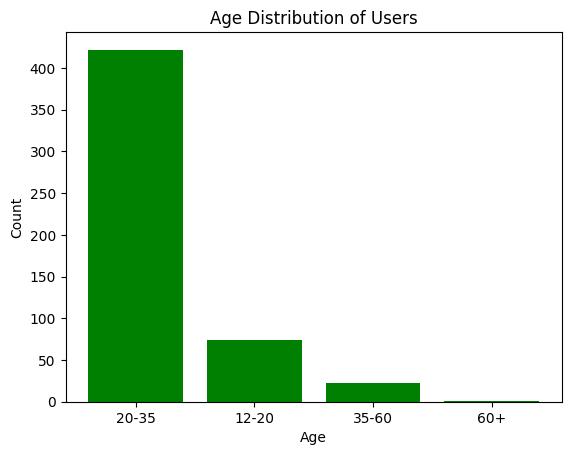

In [101]:
plt.bar(df['Age'].value_counts().index,df['Age'].value_counts().values,color='green')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution of Users')
plt.show()

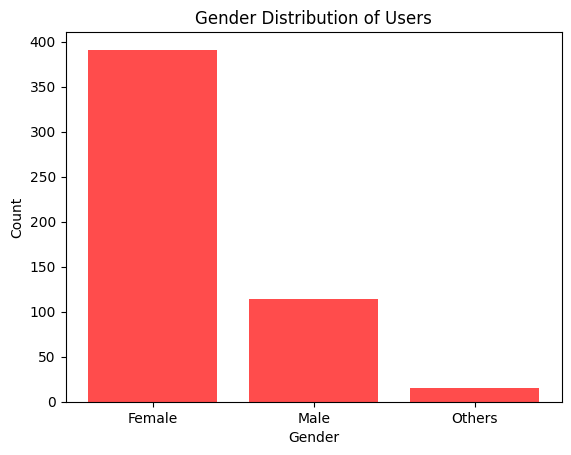

In [102]:
plt.bar(df['Gender'].value_counts().index,df['Gender'].value_counts().values,color='red',alpha=0.7)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution of Users')
plt.show()

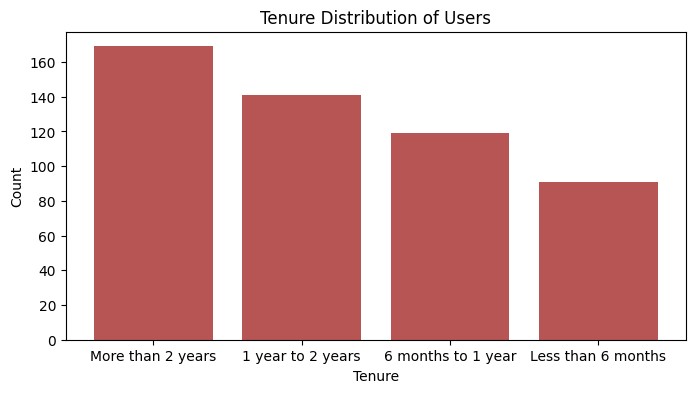

In [103]:
plt.figure(figsize=(8,4))
plt.bar(df['spotify_usage_period'].value_counts().index,df['spotify_usage_period'].value_counts().values,color='brown',alpha=0.8)
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.title('Tenure Distribution of Users')
plt.show()

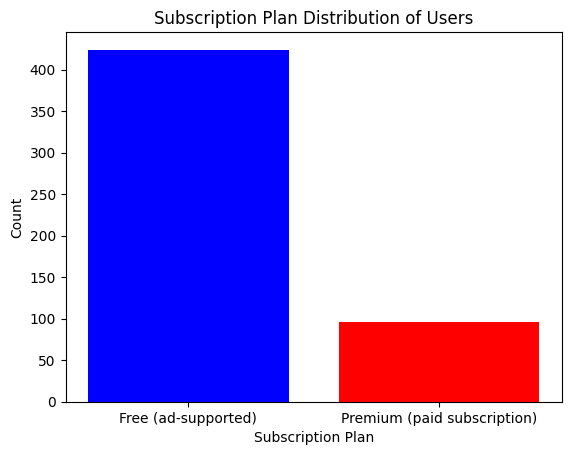

In [104]:
plt.bar(df['spotify_subscription_plan'].value_counts().index,df['spotify_subscription_plan'].value_counts().values,color=['blue','red'])
plt.xlabel('Subscription Plan')
plt.ylabel('Count')
plt.title('Subscription Plan Distribution of Users')
plt.show()

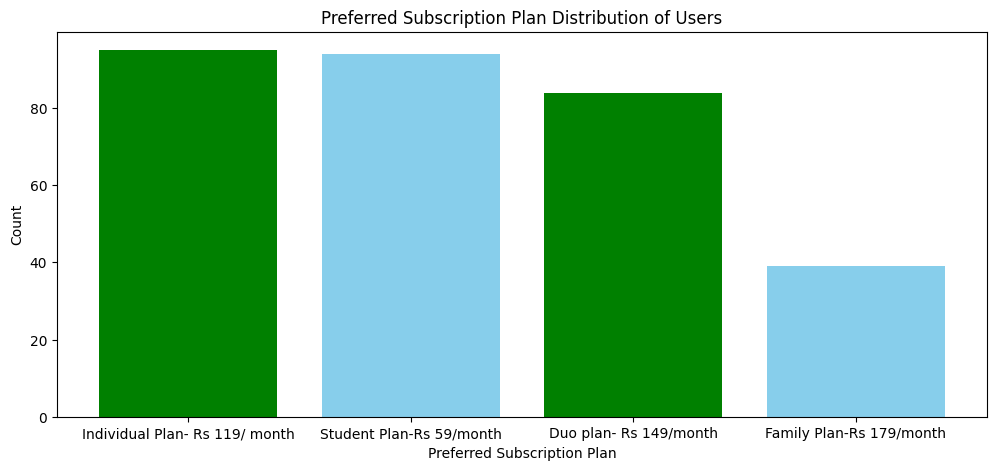

In [105]:
plt.figure(figsize=(12,5))
plt.bar(df['preffered_premium_plan'].value_counts().index,df['preffered_premium_plan'].value_counts().values,color=['green','skyblue'])
plt.xlabel('Preferred Subscription Plan')
plt.ylabel('Count')
plt.title('Preferred Subscription Plan Distribution of Users')
plt.show()

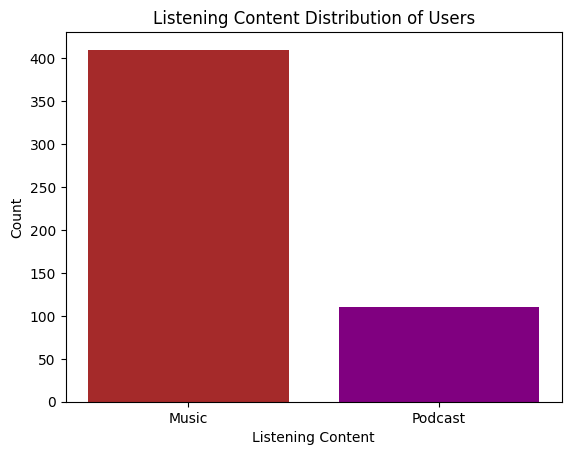

In [106]:
plt.bar(df['preferred_listening_content'].value_counts().index,df['preferred_listening_content'].value_counts().values,color=['brown','purple'])
plt.xlabel('Listening Content')
plt.ylabel('Count')
plt.title('Listening Content Distribution of Users')
plt.show()

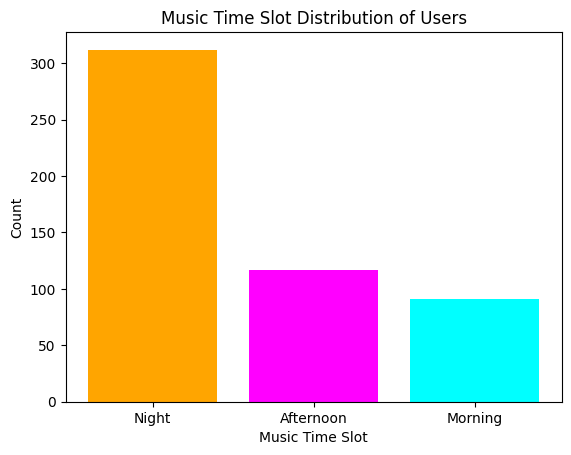

In [107]:
plt.bar(df['music_time_slot'].value_counts().index,df['music_time_slot'].value_counts().values,color=['orange','magenta','cyan'])
plt.xlabel('Music Time Slot')
plt.ylabel('Count')
plt.title('Music Time Slot Distribution of Users')
plt.show()

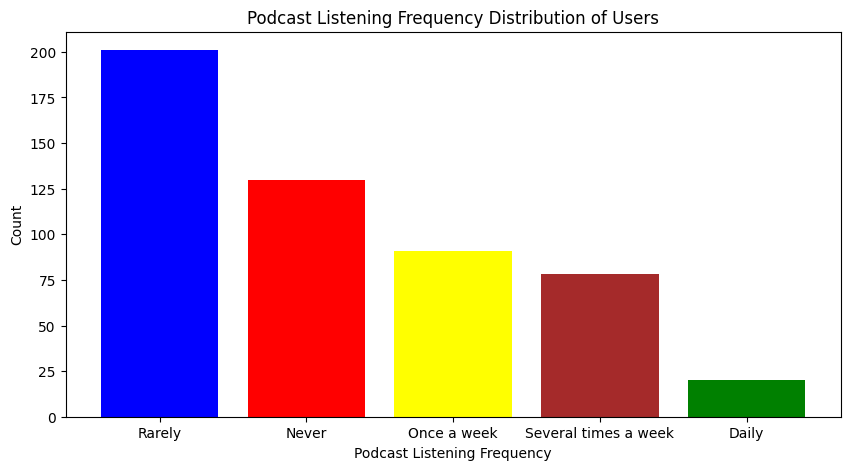

In [108]:
plt.figure(figsize=(10,5))
plt.bar(df['pod_lis_frequency'].value_counts().index,df['pod_lis_frequency'].value_counts().values,color=['blue','red','yellow','brown','green'])
plt.xlabel('Podcast Listening Frequency')
plt.ylabel('Count')
plt.title('Podcast Listening Frequency Distribution of Users')
plt.show()

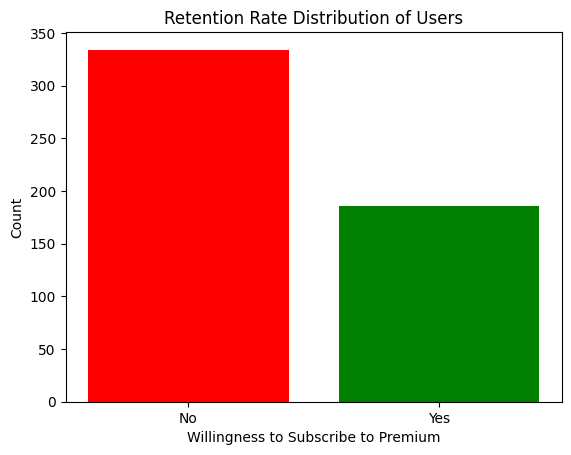

In [109]:
plt.bar(df['premium_sub_willingness'].value_counts().index,df['premium_sub_willingness'].value_counts().values,color=['red','green'])
plt.xlabel('Willingness to Subscribe to Premium')
plt.ylabel('Count')
plt.title('Retention Rate Distribution of Users')
plt.show()

In [110]:
df['Churn']=df['premium_sub_willingness'].map({'Yes':0,'No':1})
df.head()

,Age,Gender,spotify_usage_period,spotify_listening_device,spotify_subscription_plan,premium_sub_willingness,preffered_premium_plan,preferred_listening_content,fav_music_genre,music_time_slot,music_Influencial_mood,music_lis_frequency,music_expl_method,music_recc_rating,pod_lis_frequency,fav_pod_genre,preffered_pod_format,pod_host_preference,preffered_pod_duration,pod_variety_satisfaction,Churn
0,20-35,Female,More than 2 years,Smart speakers or voice assistants,Free (ad-supported),Yes,Family Plan-Rs 179/month,Podcast,Melody,Night,Sadness or melancholy,leisure time,Playlists,3,Daily,Comedy,Interview,Both,Both,Ok,0
1,12-20,Male,More than 2 years,Computer or laptop,Free (ad-supported),Yes,Individual Plan- Rs 119/ month,Podcast,Rap,Afternoon,Social gatherings or parties,Workout session,Playlists,2,Several times a week,Comedy,Interview,Both,NaN,Satisfied,0
2,35-60,Others,6 months to 1 year,Smart speakers or voice assistants,Free (ad-supported),Yes,Student Plan-Rs 59/month,Podcast,Pop,Night,Relaxation and stress relief,"Study Hours, While Traveling",Playlists,4,Once a week,Sports,Interview,NaN,Both,Satisfied,0
3,20-35,Female,1 year to 2 years,"Smartphone, Smart speakers or voice assistants",Free (ad-supported),No,NaN,Music,Melody,Night,"Relaxation and stress relief, Social gathering...","Office hours, Workout session, leisure time","recommendations, Playlists",4,Never,NaN,NaN,NaN,NaN,Ok,1
4,20-35,Female,1 year to 2 years,Smartphone,Free (ad-supported),No,NaN,Music,Melody,Night,Relaxation and stress relief,leisure time,"recommendations, Playlists",4,Rarely,Lifestyle and Health,Story telling,Well known individuals,Both,Ok,1


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Age                          520 non-null    object
 1   Gender                       520 non-null    object
 2   spotify_usage_period         520 non-null    object
 3   spotify_listening_device     520 non-null    object
 4   spotify_subscription_plan    520 non-null    object
 5   premium_sub_willingness      520 non-null    object
 6   preffered_premium_plan       312 non-null    object
 7   preferred_listening_content  520 non-null    object
 8   fav_music_genre              520 non-null    object
 9   music_time_slot              520 non-null    object
 10  music_Influencial_mood       520 non-null    object
 11  music_lis_frequency          520 non-null    object
 12  music_expl_method            520 non-null    object
 13  music_recc_rating            520 no

In [112]:
obj_cols=df.drop('premium_sub_willingness',axis=1)
obj_cols=obj_cols.select_dtypes(include='object').columns.to_list()

In [113]:
encoders={}
for col in obj_cols:
    le=LabelEncoder()
    df[col]=le.fit_transform(df[col])
    encoders[col]=le
with open('encoders.pkl','wb') as f:
    pickle.dump(encoders,f)

In [114]:
df.head()

,Age,Gender,spotify_usage_period,spotify_listening_device,spotify_subscription_plan,premium_sub_willingness,preffered_premium_plan,preferred_listening_content,fav_music_genre,music_time_slot,music_Influencial_mood,music_lis_frequency,music_expl_method,music_recc_rating,pod_lis_frequency,fav_pod_genre,preffered_pod_format,pod_host_preference,preffered_pod_duration,pod_variety_satisfaction,Churn
0,1,0,3,4,0,Yes,1,1,4,2,8,34,4,3,0,1,2,0,0,1,0
1,0,1,3,0,0,Yes,2,1,7,0,10,32,4,2,4,1,2,0,3,2,0
2,2,2,1,4,0,Yes,3,1,6,2,0,19,4,4,2,16,2,3,0,2,0
3,1,0,0,11,0,No,4,0,4,2,3,13,13,4,1,19,4,3,3,1,1
4,1,0,0,6,0,No,4,0,4,2,0,34,13,4,3,10,3,1,0,1,1


In [115]:
x=df.drop(['premium_sub_willingness','Churn'],axis=1)
y=df['Churn']
x.head()

,Age,Gender,spotify_usage_period,spotify_listening_device,spotify_subscription_plan,preffered_premium_plan,preferred_listening_content,fav_music_genre,music_time_slot,music_Influencial_mood,music_lis_frequency,music_expl_method,music_recc_rating,pod_lis_frequency,fav_pod_genre,preffered_pod_format,pod_host_preference,preffered_pod_duration,pod_variety_satisfaction
0,1,0,3,4,0,1,1,4,2,8,34,4,3,0,1,2,0,0,1
1,0,1,3,0,0,2,1,7,0,10,32,4,2,4,1,2,0,3,2
2,2,2,1,4,0,3,1,6,2,0,19,4,4,2,16,2,3,0,2
3,1,0,0,11,0,4,0,4,2,3,13,13,4,1,19,4,3,3,1
4,1,0,0,6,0,4,0,4,2,0,34,13,4,3,10,3,1,0,1


In [116]:
xtr,xte,ytr,yte=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [117]:
print(ytr.shape)
print(yte.shape)

(416,)
(104,)


In [118]:
print(ytr.value_counts())
print(yte.value_counts())

Churn
1    267
0    149
Name: count, dtype: int64
Churn
1    67
0    37
Name: count, dtype: int64


In [119]:
smote=SMOTE(random_state=42)
xtrs,ytrs=smote.fit_resample(xtr,ytr)

In [120]:
print(ytrs.value_counts())

Churn
1    267
0    267
Name: count, dtype: int64


In [121]:
models={'Decision Tree':DecisionTreeClassifier(random_state=42),
        'Random Forest':RandomForestClassifier(random_state=42),
        'XGBoost':XGBClassifier(random_state=42)}
cv_scores={}
for name,model in models.items():
    print('Training',name,'with default parameters')
    scores=cross_val_score(model,xtrs,ytrs,cv=5,scoring='accuracy')
    cv_scores[name]=scores
    print(name,'Cross Validation Accuracy Scores:',round(np.mean(scores),2))
    print('-------------------------')

Training Decision Tree with default parameters
Decision Tree Cross Validation Accuracy Scores: 0.79
-------------------------
Training Random Forest with default parameters
Random Forest Cross Validation Accuracy Scores: 0.83
-------------------------
Training XGBoost with default parameters
XGBoost Cross Validation Accuracy Scores: 0.82
-------------------------


In [122]:
dtc=DecisionTreeClassifier(random_state=42)
dtc.fit(xtrs,ytrs)
ypdtc=dtc.predict(xte)
print('Accuracy of Decision Tree Classifier:',round(accuracy_score(yte,ypdtc),2))
print('Confusion Matrix for Decision Tree Classifier:',confusion_matrix(yte,ypdtc))
print('Classification Report for Decision Tree Classifier:\n',classification_report(yte,ypdtc))

Accuracy of Decision Tree Classifier: 0.72
Confusion Matrix for Decision Tree Classifier: [[29  8]
 [21 46]]
Classification Report for Decision Tree Classifier:
               precision    recall  f1-score   support

           0       0.58      0.78      0.67        37
           1       0.85      0.69      0.76        67

    accuracy                           0.72       104
   macro avg       0.72      0.74      0.71       104
weighted avg       0.76      0.72      0.73       104



In [123]:
xgb=XGBClassifier(random_state=42)
xgb.fit(xtrs,ytrs)
ypxgb=xgb.predict(xte)
print('Accuracy of XGBoost Classifier:',round(accuracy_score(yte,ypxgb),2))
print('Confusion Matrix for XGBoost Classifier:',confusion_matrix(yte,ypxgb))
print('Classification Report for XGBoost Classifier:\n',classification_report(yte,ypxgb))

Accuracy of XGBoost Classifier: 0.74
Confusion Matrix for XGBoost Classifier: [[28  9]
 [18 49]]
Classification Report for XGBoost Classifier:
               precision    recall  f1-score   support

           0       0.61      0.76      0.67        37
           1       0.84      0.73      0.78        67

    accuracy                           0.74       104
   macro avg       0.73      0.74      0.73       104
weighted avg       0.76      0.74      0.75       104



In [124]:
rfc=RandomForestClassifier(random_state=42)
rfc.fit(xtrs,ytrs)
yprfc=rfc.predict(xte)
print('Accuracy of Random Forest Classifier:',round(accuracy_score(yte,yprfc),2))
print('Confusion Matrix for Random Forest Classifier:',confusion_matrix(yte,yprfc))
print('Classification Report for Random Forest Classifier:\n',classification_report(yte,yprfc))

Accuracy of Random Forest Classifier: 0.72
Confusion Matrix for Random Forest Classifier: [[30  7]
 [22 45]]
Classification Report for Random Forest Classifier:
               precision    recall  f1-score   support

           0       0.58      0.81      0.67        37
           1       0.87      0.67      0.76        67

    accuracy                           0.72       104
   macro avg       0.72      0.74      0.72       104
weighted avg       0.76      0.72      0.73       104



In [125]:
# Saving the best model (Random Forest Classifier, since it scored the best in cross vaidation)
model_data={'Name of model':rfc,'Feature columns':x.columns.to_list()}
with open('Customer_Churn_Model.pkl','wb') as f:
    pickle.dump(model_data,f)

In [126]:
with open('Customer_Churn_Model.pkl','rb') as f:
    model_data=pickle.load(f)
loaded_model=model_data['Name of model']
features=model_data['Feature columns']

In [127]:
print(loaded_model)

RandomForestClassifier(random_state=42)


In [128]:
print(features)

['Age', 'Gender', 'spotify_usage_period', 'spotify_listening_device', 'spotify_subscription_plan', 'preffered_premium_plan', 'preferred_listening_content', 'fav_music_genre', 'music_time_slot', 'music_Influencial_mood', 'music_lis_frequency', 'music_expl_method', 'music_recc_rating', 'pod_lis_frequency', 'fav_pod_genre', 'preffered_pod_format', 'pod_host_preference', 'preffered_pod_duration', 'pod_variety_satisfaction']


In [129]:
spotify_user_data = {"Age": "20-35",
    "Gender": "Female",
    "spotify_usage_period": "More than 2 years",
    "spotify_listening_device": "Smart speakers or voice assistants",
    "spotify_subscription_plan": "Free (ad-supported)",
    "preffered_premium_plan": "Family Plan-Rs 179/month",
    "preferred_listening_content": "Podcast",
    "fav_music_genre": "Melody",
    "music_time_slot": "Night",
    "music_Influencial_mood": "Sadness or melancholy",
    "music_lis_frequency": "leisure time",
    "music_expl_method": "Playlists",
    "music_recc_rating": 3,
    "pod_lis_frequency": "Daily",
    "fav_pod_genre": "Comedy",
    "preffered_pod_format": "Interview",
    "pod_host_preference": "Both",
    "preffered_pod_duration": "Both",
    "pod_variety_satisfaction": "Ok"}

In [130]:
input_df=pd.DataFrame([spotify_user_data])
with open ('encoders.pkl','rb') as f:
    encoders=pickle.load(f)
print(input_df.head())
for col,encoder in encoders.items():
    input_df[col]=encoder.transform(input_df[col])

     Age  Gender spotify_usage_period            spotify_listening_device  \
0  20-35  Female    More than 2 years  Smart speakers or voice assistants   

  spotify_subscription_plan    preffered_premium_plan  \
0       Free (ad-supported)  Family Plan-Rs 179/month   

  preferred_listening_content fav_music_genre music_time_slot  \
0                     Podcast          Melody           Night   

  music_Influencial_mood music_lis_frequency music_expl_method  \
0  Sadness or melancholy        leisure time         Playlists   

   music_recc_rating pod_lis_frequency fav_pod_genre preffered_pod_format  \
0                  3             Daily        Comedy            Interview   

  pod_host_preference preffered_pod_duration pod_variety_satisfaction  
0                Both                   Both                       Ok  


In [131]:
input_df.head()

,Age,Gender,spotify_usage_period,spotify_listening_device,spotify_subscription_plan,preffered_premium_plan,preferred_listening_content,fav_music_genre,music_time_slot,music_Influencial_mood,music_lis_frequency,music_expl_method,music_recc_rating,pod_lis_frequency,fav_pod_genre,preffered_pod_format,pod_host_preference,preffered_pod_duration,pod_variety_satisfaction
0,1,0,3,4,0,1,1,4,2,8,34,4,3,0,1,2,0,0,1


In [133]:
prediction= loaded_model.predict(input_df)
pred_prob=loaded_model.predict_proba(input_df)
print(f"Prediction: {'Churn' if prediction[0]==1 else 'No churn'}")
print(f'Prediction probability: {pred_prob[0]}')

Prediction: No churn
Prediction probability: [0.93 0.07]
